# Dementia Risk Prediction — Logistic Regression Model

**Project:** `ml_dementia` · **Notebook:** `modelx.ipynb` · **Data:** `data.csv` (synthetic mirror of the `dementia_screening` table)

This notebook implements the analysis plan in [`plan.md`](plan.md) **§6.1** end-to-end:

| Stage (plan §6.1) | Section in this notebook |
|---|---|
| 1. Ingest | §2 |
| 2. Cleaning (noise-manifest driven) | §4 |
| 3. Preprocessing (split-first, impute-on-train, one-hot) | §5 |
| 4. Logistic regression modelling | §6 |
| 5–6. Validation & metrics (CV + hold-out) | §6 |
| 7. Interpretability (ORs, forest plot) | §7 |
| 8. Subgroup performance | §8 |

> ⚠️ **Disclaimer (plan §5.1):** the dataset is **synthetic** — it contains no real patient records.
> It was generated to be statistically plausible for a Zimbabwean 60+ community sample so that the
> full cleaning → preprocessing → modelling → reporting pipeline can be rehearsed before any real
> collection. **All results below are illustrative and must never be quoted as findings about Zimbabwe.**

## 1. Setup

Standard scientific-Python stack (plan §6.3): `pandas`, `numpy`, `matplotlib`/`seaborn` for EDA,
`scikit-learn` for the modelling pipeline, and `statsmodels` for unpenalised logistic regression
with confidence intervals on the odds ratios. A single fixed random seed guarantees
reproducibility of the split, cross-validation folds, and model initialisation.

In [2]:
# --- Core stack ---
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelling stack ---
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             brier_score_loss, classification_report,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# calibration_curve moved between submodules across sklearn versions.
try:
    from sklearn.metrics import calibration_curve
except ImportError:
    from sklearn.calibration import calibration_curve

import statsmodels.api as sm

# --- Reproducibility & display ---
RANDOM_STATE = 42          # single seed for split, CV folds and estimators (plan §6.1.3)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Output artefacts (clean table, rejection log, OR table, hold-out metrics)
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Environment ready — pandas", pd.__version__)

Environment ready — pandas 3.0.3


## 2. Ingest & First Look

`data.csv` is the flat mirror of the `dementia_screening` table (plan §5.1); NULLs are empty
fields. We read with `keep_default_na=False` so that survey strings such as `"None"`
(alcohol use) survive as genuine category labels rather than being parsed as missing — only
truly empty fields become `NaN`.

In [3]:
# Load raw data. keep_default_na=False + na_values=[""] -> only empty fields are NaN.
df = pd.read_csv("data.csv", keep_default_na=False, na_values=[""])
print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Raw shape: 12,168 rows x 31 columns


,participant_id,interview_date,province,residence,sex,age_years,marital_status,education_years,employment_status,monthly_household_income_usd,lives_alone,social_engagement,hiv_status,hypertension_dx,takes_bp_medication,diabetes_dx,prior_stroke,head_injury_history,family_history_dementia,systolic_bp_mmhg,diastolic_bp_mmhg,bmi_kg_m2,gds15_score,hearing_difficulty,vision_difficulty,smoking_status,alcohol_use,physical_activity_level,fruit_veg_servings_per_day,cognitive_screen_score,dementia_status
0,ZW-00001,12/11/2024,Mashonaland West,Urban,F,62,Married,6.0,Unemployed,20.0,0,Daily,Negative,1,0.0,0,0,0.0,0.0,151.0,92.0,16.8,2.0,0.0,0.0,Never,None,High,2.0,25.0,0
1,ZW-00002,2024-05-12,Manicaland,Urban,F,61,Widowed,7.0,Retired,65.0,0,Daily,Negative,0,0.0,0,0,0.0,0.0,113.0,85.0,22.6,2.0,0.0,0.0,Never,None,Low,6.0,24.0,0
2,ZW-00003,23/02/2024,Harare,Urban,M,68,Widowed,NaN,Unemployed,45.0,1,Daily,Negative,0,0.0,0,0,0.0,0.0,99.0,90.0,21.1,4.0,0.0,0.0,Never,None,Low,4.0,25.0,0
3,ZW-00004,2024-09-23,Masvingo,Rural,F,61,Widowed,3.0,Retired,15.0,0,Daily,Negative,0,0.0,0,1,0.0,0.0,118.0,84.0,16.5,3.0,0.0,0.0,Never,None,High,5.0,29.0,0
4,ZW-00005,19/04/2024,Mashonaland West,Urban,M,66,Married,8.0,Retired,NaN,1,Never,Negative,1,0.0,0,0,0.0,0.0,175.0,NaN,14.4,3.0,0.0,0.0,Former,None,High,5.0,27.0,0


In [4]:
# Structure overview: dtypes and non-null counts per column.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12168 entries, 0 to 12167
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   participant_id                12168 non-null  str    
 1   interview_date                12168 non-null  str    
 2   province                      12168 non-null  str    
 3   residence                     12168 non-null  str    
 4   sex                           12168 non-null  str    
 5   age_years                     12168 non-null  int64  
 6   marital_status                12048 non-null  str    
 7   education_years               11929 non-null  float64
 8   employment_status             12054 non-null  str    
 9   monthly_household_income_usd  10428 non-null  float64
 10  lives_alone                   12168 non-null  int64  
 11  social_engagement             11922 non-null  str    
 12  hiv_status                    12168 non-null  str    
 13  hypertension

In [5]:
# Numeric summary of the RAW data.
# Impossible values are already visible (age max 999, BMI 4.7-102.5, education 51)
# — these are engineered defects from the noise manifest (plan §5.3), handled in §4.
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age_years,12168.0,69.7,37.8,-5.0,62.0,65.0,71.0,999.0
education_years,11929.0,2.8,15.2,-99.0,2.0,5.0,7.0,51.0
monthly_household_income_usd,10428.0,103.8,120.0,0.0,35.0,65.0,120.0,800.0
lives_alone,12168.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0
hypertension_dx,12168.0,0.5,0.5,0.0,0.0,1.0,1.0,1.0
takes_bp_medication,11831.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0
diabetes_dx,12168.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0
prior_stroke,12168.0,0.0,0.2,0.0,0.0,0.0,0.0,1.0
head_injury_history,11942.0,0.1,0.2,0.0,0.0,0.0,0.0,1.0
family_history_dementia,11936.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0


## 3. Exploratory Data Analysis (raw, pre-cleaning)

Purpose: audit the **raw state** of the data against the `noise_manifest` (plan §5.3) *before*
any repair, so that every cleaning decision in §4 is evidence-based and nothing is fixed
silently. We look at (3.1) the outcome, (3.2) missingness, (3.3) numeric distributions,
(3.4) categorical chaos, (3.5) crude outcome associations, and (3.6) correlations.

### 3.1 Outcome variable — `dementia_status`

Binary 0/1 clinician-consensus outcome (plan §4.1). The ~8% prevalence matches the
calibration target (plan §5.2) and confirms the class imbalance flagged in plan §8 —
it motivates stratified splitting, PR-AUC alongside ROC-AUC, and sensitivity-first
operating points later in §6.

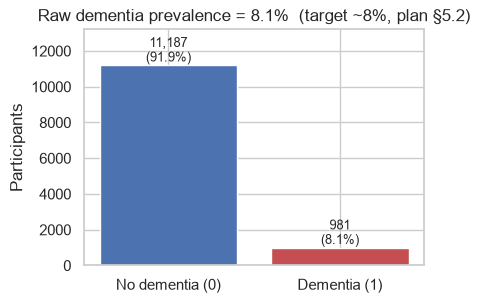

In [6]:
# Prevalence of dementia in the raw file (duplicates still included at this stage).
counts = df["dementia_status"].value_counts().sort_index()
prevalence = df["dementia_status"].mean()

fig, ax = plt.subplots(figsize=(4.5, 3.2))
bars = ax.bar(["No dementia (0)", "Dementia (1)"], counts.values,
              color=["#4c72b0", "#c44e52"])
for b, n in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, n, f"{n:,}\n({n/len(df):.1%})",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_ylabel("Participants")
ax.set_title(f"Raw dementia prevalence = {prevalence:.1%}  (target ~8%, plan §5.2)")
plt.tight_layout(); plt.show()

### 3.2 Missingness profile (true NULLs only)

This counts *true empty fields* only — sentinel codes (`-99`, `88`, `99`) have not yet been
converted, so real missingness is higher than shown here (see §4.3). Income stands out,
matching the MAR defect (rural under-reporting, manifest row 2); a missing-indicator flag
is added during preprocessing (§5).

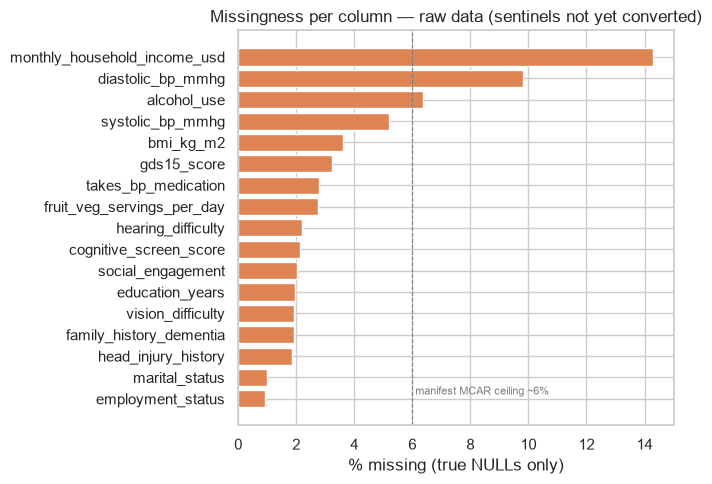

,% missing
monthly_household_income_usd,14.30
diastolic_bp_mmhg,9.81
alcohol_use,6.35
systolic_bp_mmhg,5.19
bmi_kg_m2,3.60
gds15_score,3.25
takes_bp_medication,2.77
fruit_veg_servings_per_day,2.76
hearing_difficulty,2.19
cognitive_screen_score,2.12


In [7]:
# Percentage of true NULLs per column (sorted; only columns with any missingness shown).
miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], color="#dd8452")
ax.set_xlabel("% missing (true NULLs only)")
ax.set_title("Missingness per column — raw data (sentinels not yet converted)")
ax.axvline(6, ls="--", c="grey", lw=0.8)
ax.text(6.1, 0.2, "manifest MCAR ceiling ~6%", fontsize=8, color="grey")
plt.tight_layout(); plt.show()

display(miss_pct.round(2).to_frame("% missing"))

### 3.3 Numeric distributions

Histograms of the key numeric fields. Watch for: impossible ages (999), BMI extreme spikes,
education beyond any plausible schooling, negative fruit/veg servings, and sentinel pile-ups.

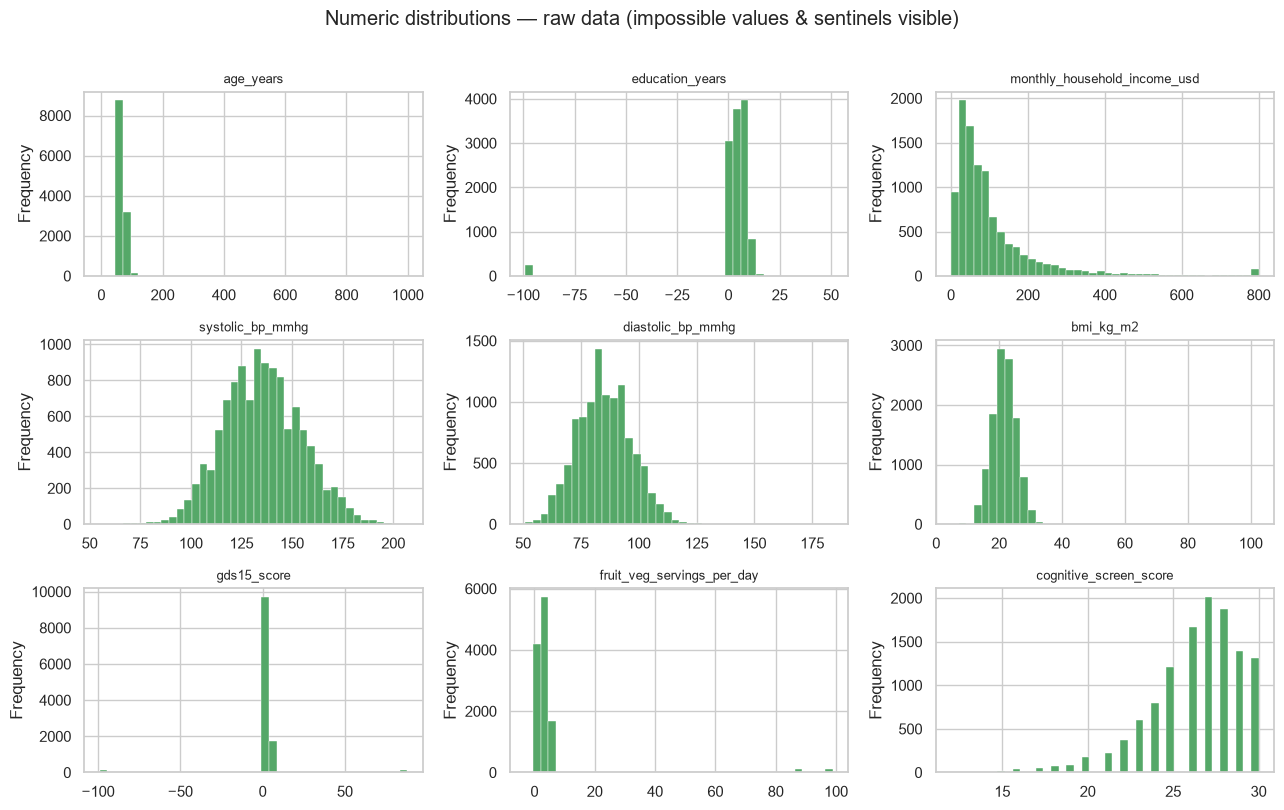

In [8]:
# Distribution grid for the main numeric variables (raw values).
num_cols = ["age_years", "education_years", "monthly_household_income_usd",
            "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2",
            "gds15_score", "fruit_veg_servings_per_day", "cognitive_screen_score"]

fig, axes = plt.subplots(3, 3, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col].plot.hist(bins=40, ax=ax, color="#55a868", edgecolor="white", lw=0.3)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Numeric distributions — raw data (impossible values & sentinels visible)", y=1.01)
plt.tight_layout(); plt.show()

### 3.4 Categorical chaos (manifest row 10)

Raw category labels mix case variants, trailing whitespace, abbreviations (`Hre`, `Mat North`)
and misspellings (`widwoed`, `Rual`). Each panel below is one categorical column's raw value
counts — the fragmentation (e.g. >25 distinct 'provinces' for a 10-province country) is exactly
what §4.5 harmonises.

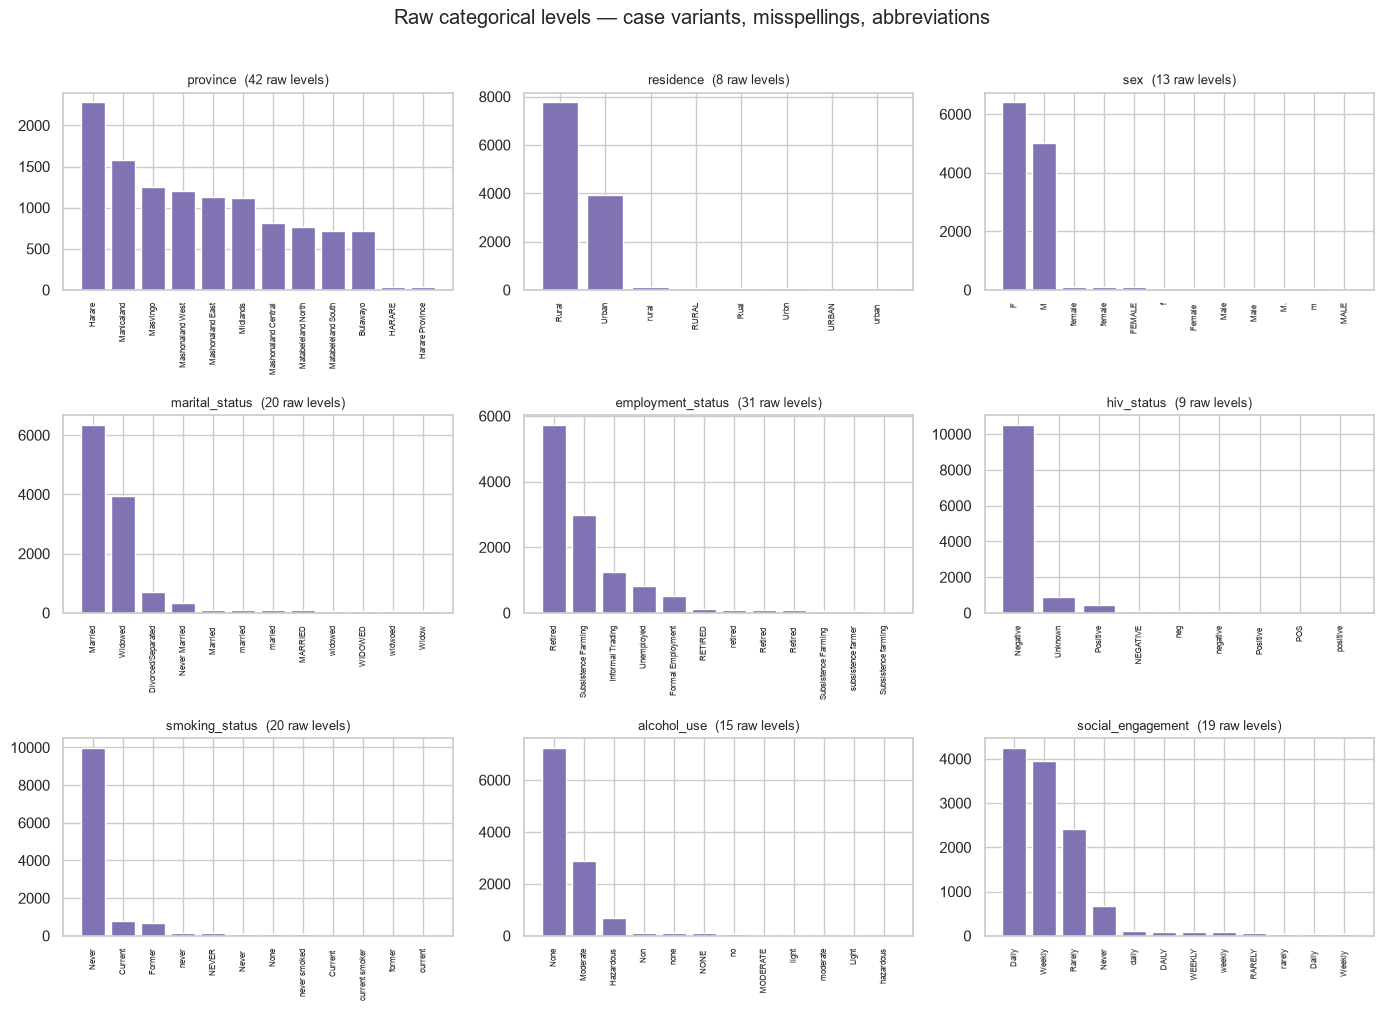

In [9]:
# Raw category frequencies — the mess is the message.
cat_cols = ["province", "residence", "sex", "marital_status", "employment_status",
            "hiv_status", "smoking_status", "alcohol_use", "social_engagement"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].value_counts().head(12)
    ax.bar(range(len(vc)), vc.values, color="#8172b3")
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=90, fontsize=6)
    ax.set_title(f"{col}  ({df[col].nunique()} raw levels)", fontsize=9)
fig.suptitle("Raw categorical levels — case variants, misspellings, abbreviations", y=1.01)
plt.tight_layout(); plt.show()

### 3.5 Crude outcome associations

Prevalence of dementia by key predictors (inline canonicalisation of labels used for
plotting only — proper harmonisation happens in §4.5). Expected gradient per plan §1.3 (H1):
rising with age, falling with education; higher among the hearing-impaired.

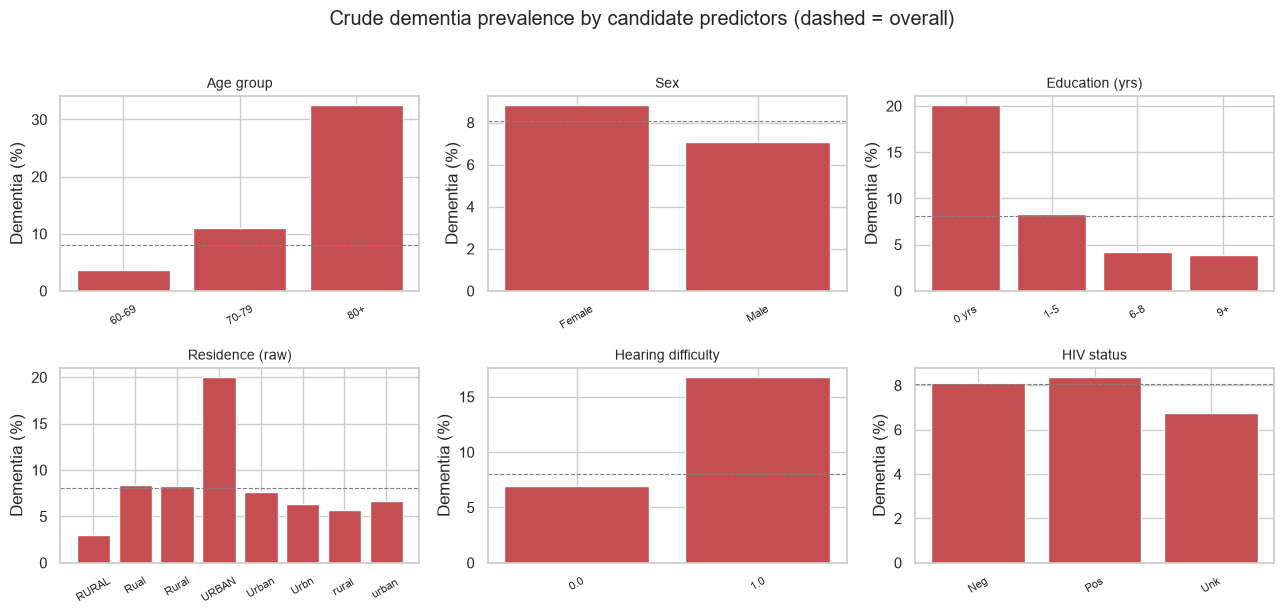

In [10]:
# Crude prevalence by grouping variables (display-only label clean-up).
eda = df.copy()
eda["sex_u"] = eda["sex"].str.strip().str.upper().str[0].map({"M": "Male", "F": "Female"})
eda["hiv_u"] = eda["hiv_status"].str.strip().str.lower().map(
    {"negative": "Neg", "positive": "Pos", "unknown": "Unk"})
eda["age_group"] = pd.cut(eda["age_years"], [0, 69, 79, 110],
                          labels=["60-69", "70-79", "80+"])
eda["edu_band"] = pd.cut(eda["education_years"], [-1, 0, 5, 8, 30],
                         labels=["0 yrs", "1-5", "6-8", "9+"])

panels = [("age_group", "Age group"), ("sex_u", "Sex"), ("edu_band", "Education (yrs)"),
          ("residence", "Residence (raw)"), ("hearing_difficulty", "Hearing difficulty"),
          ("hiv_u", "HIV status")]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (col, title) in zip(axes.flat, panels):
    prev = eda.groupby(col, observed=True)["dementia_status"].mean().sort_index()
    ax.bar(prev.index.astype(str), prev.values * 100, color="#c44e52")
    ax.axhline(eda["dementia_status"].mean() * 100, ls="--", c="grey", lw=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Dementia (%)")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
fig.suptitle("Crude dementia prevalence by candidate predictors (dashed = overall)", y=1.02)
plt.tight_layout(); plt.show()

### 3.6 Correlation structure (numeric fields)

Pearson correlations among numeric variables and the outcome. We check for (a) strong
predictor–predictor collinearity that would destabilise LR coefficients, and (b) the
`cognitive_screen_score` ↔ `dementia_status` correlation — the score is partly derived from
the same latent propensity as the outcome (plan §5.4), which is why it is **quarantined from
the predictor pool** (§5).

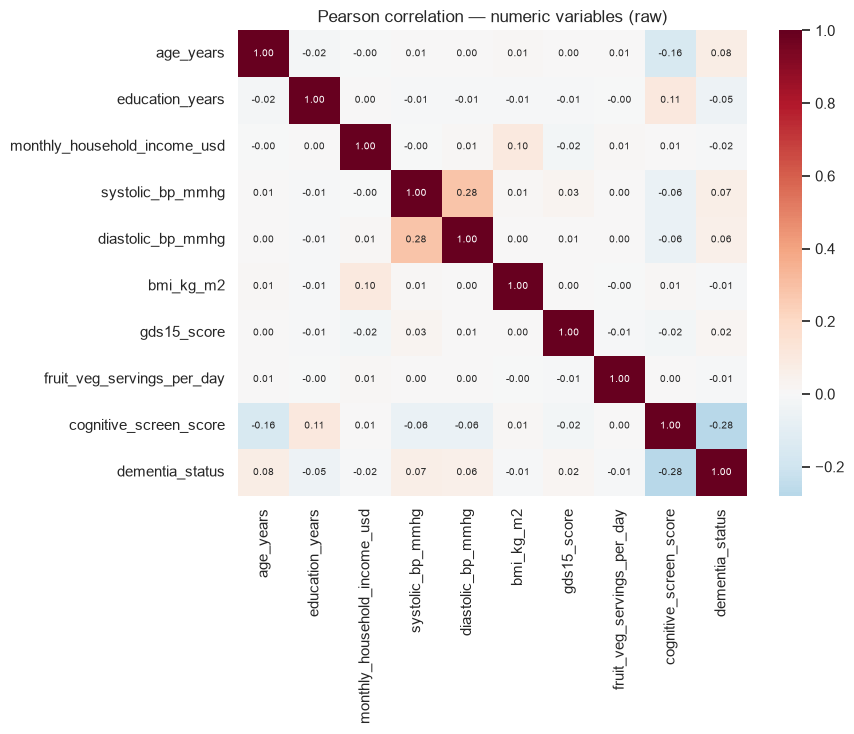

Correlation of cognitive_screen_score with outcome: -0.28  (leakage risk -> quarantined, plan §4.2H)


In [11]:
# Correlation heatmap of numeric variables incl. outcome.
corr_cols = num_cols + ["dementia_status"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Pearson correlation — numeric variables (raw)")
plt.tight_layout(); plt.show()

print("Correlation of cognitive_screen_score with outcome:",
      round(df['cognitive_screen_score'].corr(df['dementia_status']), 3),
      " (leakage risk -> quarantined, plan §4.2H)")

## 4. Data Cleaning (driven by the `noise_manifest`)

Every operation below maps to a manifest row (plan §5.3). Governing principles from plan §6.1.2:

1. **Deduplicate first** on `participant_id` (documented conflict rule).
2. **Never silently overwrite** — repairs are counted; rows that cannot be repaired go to an
   explicit **rejection log** with a reason.
3. Sentinels → `NaN` *before* any arithmetic.
4. Harmonise categories against controlled vocabularies (case-fold, trim, map synonyms).
5. Apply the eligibility rule **age ≥ 60** last, and report the excluded count.

In [12]:
# Working copy + explicit rejection log (plan §6.1.2: "explicit rejection log, never silent").
clean = df.copy()
rejection_log = []   # one entry per dropped row-set: (reason, n_rows)

def reject(mask, reason):
    """Remove rows matching `mask` and record why (audit trail for the report)."""
    n = int(mask.sum())
    if n:
        rejection_log.append({"reason": reason, "n_rows": n})
        clean.drop(clean.index[mask], inplace=True)
    return n

### 4.1 Trim whitespace (manifest row 11) & deduplicate (rows 4–5)

* **Exact duplicates** (~120 rows): all 31 fields identical → drop.
* **Fuzzy duplicates** (~48 rows): same `participant_id` with minor jitter (e.g. age ±1)
  → keep the **first occurrence**, per the manifest's recommended conflict rule.

In [13]:
# (a) Trim leading/trailing whitespace on every text column — cheap, safe, done first.
text_cols = clean.select_dtypes(include="object").columns
clean[text_cols] = clean[text_cols].apply(lambda s: s.str.strip())
print(f"Whitespace trimmed on {len(text_cols)} text columns")

# (b) Exact duplicates: identical across all columns.
n_exact = int(clean.duplicated().sum())
clean = clean.drop_duplicates()
print(f"Exact duplicate rows dropped: {n_exact}")

# (c) Fuzzy duplicates: same participant_id, jittered fields -> keep first occurrence.
n_ids = clean["participant_id"].duplicated().sum()
clean = clean.drop_duplicates(subset="participant_id", keep="first")
print(f"Fuzzy duplicate ids resolved (kept first): {n_ids}")
print(f"Shape after dedup: {clean.shape}")

Whitespace trimmed on 12 text columns
Exact duplicate rows dropped: 120
Fuzzy duplicate ids resolved (kept first): 48
Shape after dedup: (12000, 31)


C:\Users\TinoL\AppData\Local\Temp\ipykernel_25872\1137258323.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = clean.select_dtypes(include="object").columns


### 4.2 Parse inconsistent dates (manifest row 12)

Three formats coexist: ISO (`2024-05-12`), day-first slash (`12/05/2024`) and
`May 12, 2024`. We parse each explicitly and combine; unparseable dates become `NaT` and are
counted (fail loudly, never guessed). Dates are not model predictors but are kept for
survey-timeliness audits.

In [14]:
# Explicit multi-format parser (plan §6.1.2 "parse dates").
DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%b %d, %Y"]
parsed = pd.Series(pd.NaT, index=clean.index, dtype="datetime64[ns]")
for fmt in DATE_FORMATS:
    parsed = parsed.fillna(pd.to_datetime(clean["interview_date"], format=fmt, errors="coerce"))

n_bad = parsed.isna().sum()
clean["interview_date"] = parsed
print(f"Parsed: {parsed.notna().sum():,} | unparseable -> NaT: {n_bad}")
print("Interview date range:", parsed.min().date(), "to", parsed.max().date())

Parsed: 12,000 | unparseable -> NaT: 0
Interview date range: 2024-01-08 to 2025-03-31


### 4.3 Survey sentinel codes → `NaN` (manifest row 3)

Per the manifest, sentinels were injected **only** into `income`, `education`, `GDS-15` and
`fruit/veg`. (Age 88/99 and diastolic 88 are *genuine* values — verified in §3.3 by the
absence of distribution spikes — so they are untouched.)
Mapping: `-99` = refusal, `88` = don't know, `99` = not applicable → all to `NaN` before
any arithmetic.

In [15]:
# Convert sentinel codes to NaN on the affected columns only (manifest row 3).
SENTINELS = {-99: "refusal", 88: "don't know", 99: "not applicable"}
SENTINEL_COLS = ["monthly_household_income_usd", "education_years",
                 "gds15_score", "fruit_veg_servings_per_day"]

sentinel_report = []
for col in SENTINEL_COLS:
    hits = clean[col].isin(SENTINELS)
    sentinel_report.append({"column": col, "n_sentinel_cells": int(hits.sum())})
    clean.loc[hits, col] = np.nan
display(pd.DataFrame(sentinel_report))

,column,n_sentinel_cells
0,monthly_household_income_usd,291
1,education_years,242
2,gds15_score,261
3,fruit_veg_servings_per_day,203


### 4.4 Impossible & out-of-range values (manifest rows 6–9)

Two routes, never silent:

* **Repair where the error mechanism is unambiguous** — BP transposition
  (diastolic ≥ systolic): swap the pair, keep if both become plausible.
* **`NaN` for implausible-but-nonidentifying cells** (BMI, education, GDS, servings) →
  imputed later on training data only.
* **Row rejection** only for age: ages outside plausibility (e.g. `999`, `-5`, `160`) or the
  missing-age case cannot satisfy the ≥60 eligibility rule, so the record is unusable for the
  analysis and goes to the rejection log.

In [16]:
# --- (a) Range checks: out-of-range cells -> NaN (counted, flagged) -----------------
RANGES = {                      # (lo, hi) plausible physiological/domain bounds
    "bmi_kg_m2":                 (10, 70),      # manifest row 7
    "education_years":           (0, 20),       # manifest row 9 (max ~16-20 schooling yrs)
    "gds15_score":               (0, 15),       # GDS-15 instrument bounds
    "fruit_veg_servings_per_day": (0, 20),
    "systolic_bp_mmhg":          (70, 250),
    "diastolic_bp_mmhg":         (40, 150),
    "cognitive_screen_score":    (0, 30),
    "monthly_household_income_usd": (0, 5000),
}
range_report = []
for col, (lo, hi) in RANGES.items():
    bad = ~clean[col].between(lo, hi) & clean[col].notna()
    range_report.append({"column": col, "out_of_range_cells": int(bad.sum()),
                         "bounds": f"[{lo}, {hi}]"})
    clean.loc[bad, col] = np.nan
display(pd.DataFrame(range_report))

,column,out_of_range_cells,bounds
0,bmi_kg_m2,40,"[10, 70]"
1,education_years,32,"[0, 20]"
2,gds15_score,24,"[0, 15]"
3,fruit_veg_servings_per_day,16,"[0, 20]"
4,systolic_bp_mmhg,6,"[70, 250]"
5,diastolic_bp_mmhg,15,"[40, 150]"
6,cognitive_screen_score,0,"[0, 30]"
7,monthly_household_income_usd,0,"[0, 5000]"


In [17]:
# --- (b) BP transposition: diastolic >= systolic -> swap if plausible (row 8) --------
transposed = clean["diastolic_bp_mmhg"].notna() & clean["systolic_bp_mmhg"].notna() \
             & (clean["diastolic_bp_mmhg"] >= clean["systolic_bp_mmhg"])
swap_ok = transposed & clean["diastolic_bp_mmhg"].between(70, 250) \
                     & clean["systolic_bp_mmhg"].between(40, 150)

sys_v, dia_v = clean.loc[swap_ok, "systolic_bp_mmhg"], clean.loc[swap_ok, "diastolic_bp_mmhg"]
clean.loc[swap_ok, "systolic_bp_mmhg"] = dia_v.values   # swap
clean.loc[swap_ok, "diastolic_bp_mmhg"] = sys_v.values
clean.loc[transposed & ~swap_ok, ["systolic_bp_mmhg", "diastolic_bp_mmhg"]] = np.nan

print(f"BP transpositions: {int(transposed.sum())} found | "
      f"{int(swap_ok.sum())} repaired by swapping | "
      f"{int((transposed & ~swap_ok).sum())} unrepairable -> NaN")

BP transpositions: 61 found | 61 repaired by swapping | 0 unrepairable -> NaN


In [18]:
# --- (c) Age: reject impossible / missing ages (row 6) ------------------------------
n_before = len(clean)
reject(clean["age_years"].isna(), "age missing (incl. sentinel-corrupted) — eligibility unverifiable")
reject(clean["age_years"] > 110, "impossible age (>110, e.g. 999/160) — rejection log")
print(f"Age-based rejections so far: {n_before - len(clean)} rows")

Age-based rejections so far: 56 rows


### 4.5 Harmonise categoricals to controlled vocabularies (manifest row 10)

Three steps: **case-fold + collapse spaces** → **mapping table of synonyms/abbreviations/misspellings**
→ residual unmapped labels become `NaN` (counted; should be zero). Vocabularies follow plan §4.2
(e.g. 10 canonical provinces, Never/Former/Current smoking).

In [19]:
# Canonical vocabularies: map normalised (casefolded) label -> canonical label.
PROVINCE_MAP = {
    "harare": "Harare", "harare province": "Harare", "hre": "Harare",
    "bulawayo": "Bulawayo",
    "manicaland": "Manicaland",
    "mashonaland central": "Mashonaland Central", "mash central": "Mashonaland Central",
    "mashonaland east": "Mashonaland East", "mash east": "Mashonaland East",
    "mashonaland west": "Mashonaland West", "mash west": "Mashonaland West",
    "masvingo": "Masvingo",
    "matabeleland north": "Matabeleland North", "mat north": "Matabeleland North",
    "matabeleland south": "Matabeleland South", "mat south": "Matabeleland South",
    "midlands": "Midlands",
}
RESIDENCE_MAP = {"urban": "Urban", "urbn": "Urban", "rural": "Rural", "rual": "Rural"}
SEX_MAP = {"m": "Male", "male": "Male", "m.": "Male", "f": "Female", "female": "Female"}
MARITAL_MAP = {
    "married": "Married", "maried": "Married",
    "widowed": "Widowed", "widow": "Widowed", "widwoed": "Widowed",
    "divorced": "Divorced/Separated", "divorced/separated": "Divorced/Separated",
    "divorced / separated": "Divorced/Separated", "divorced/seperated": "Divorced/Separated",
    "never married": "Never Married", "never-married": "Never Married", "single": "Never Married",
}
EMPLOYMENT_MAP = {
    "retired": "Retired",
    "subsistence farming": "Subsistence Farming", "subsistence farmer": "Subsistence Farming",
    "farming": "Subsistence Farming",
    "informal trading": "Informal Trading", "informal trade": "Informal Trading",
    "vendor": "Informal Trading",
    "formal employment": "Formal Employment", "formal": "Formal Employment",
    "formal sector": "Formal Employment",
    "unemployed": "Unemployed", "not employed": "Unemployed",
}
HIV_MAP = {"negative": "Negative", "neg": "Negative",
           "positive": "Positive", "pos": "Positive", "unknown": "Unknown"}
SMOKING_MAP = {"never": "Never", "never smoked": "Never", "none": "Never",
               "former": "Former", "ex-smoker": "Former", "ex smoker": "Former",
               "current": "Current", "current smoker": "Current", "yes": "Current"}
ALCOHOL_MAP = {"none": "None", "no": "None", "non": "None",
               "moderate": "Moderate", "light": "Moderate",
               "hazardous": "Hazardous", "heavy": "Hazardous", "heavy drinker": "Hazardous"}
ACTIVITY_MAP = {"low": "Low", "moderate": "Moderate", "high": "High"}
SOCIAL_MAP = {"daily": "Daily", "weekly": "Weekly", "rarely": "Rarely", "never": "Never"}

VOCABS = {"province": PROVINCE_MAP, "residence": RESIDENCE_MAP, "sex": SEX_MAP,
          "marital_status": MARITAL_MAP, "employment_status": EMPLOYMENT_MAP,
          "hiv_status": HIV_MAP, "smoking_status": SMOKING_MAP, "alcohol_use": ALCOHOL_MAP,
          "physical_activity_level": ACTIVITY_MAP, "social_engagement": SOCIAL_MAP}

harmonise_report = []
for col, vocab in VOCABS.items():
    n_levels_before = clean[col].nunique()
    normed = clean[col].str.lower().str.replace(r"\s+", " ", regex=True)  # casefold + collapse spaces
    clean[col] = normed.map(vocab)                                          # unmapped -> NaN
    unmapped = clean[col].isna() & normed.notna()
    harmonise_report.append({"column": col, "raw_levels": n_levels_before,
                             "canonical_levels": clean[col].nunique(),
                             "unmapped_to_nan": int(unmapped.sum())})
display(pd.DataFrame(harmonise_report))

,column,raw_levels,canonical_levels,unmapped_to_nan
0,province,38,10,21
1,residence,8,2,0
2,sex,11,2,0
3,marital_status,18,4,0
4,employment_status,21,5,0
5,hiv_status,8,3,0
6,smoking_status,15,3,0
7,alcohol_use,15,3,0
8,physical_activity_level,3,3,0
9,social_engagement,11,4,0


In [20]:
# Tidy small dtypes: lives_alone arrives as string '0'/'1' -> integer flag.
clean["lives_alone"] = pd.to_numeric(clean["lives_alone"], errors="coerce").astype("Int64")

# Confirm canonical vocabularies landed correctly.
for col in ["province", "sex", "residence", "smoking_status", "alcohol_use"]:
    print(f"{col:>22}: {sorted(clean[col].dropna().unique())}")

              province: ['Bulawayo', 'Harare', 'Manicaland', 'Mashonaland Central', 'Mashonaland East', 'Mashonaland West', 'Masvingo', 'Matabeleland North', 'Matabeleland South', 'Midlands']
                   sex: ['Female', 'Male']
             residence: ['Rural', 'Urban']
        smoking_status: ['Current', 'Former', 'Never']
           alcohol_use: ['Hazardous', 'Moderate', 'None']


### 4.6 Logical contradictions (manifest row 13)

~80 records claim `takes_bp_medication = 1` while `hypertension_dx = 0`. The manifest offers
*keep-as-missing* vs *keep-with-flag*; we choose **keep-as-missing**: the diagnosis field is the
more reliable of the two, so the contradictory medication value is set to `NaN` (imputed later).
The choice is documented here for the report.

In [21]:
# Contradiction: on BP medication but no hypertension diagnosis -> medication to NaN.
contra = (clean["takes_bp_medication"] == 1) & (clean["hypertension_dx"] == 0)
clean.loc[contra, "takes_bp_medication"] = np.nan
print(f"Contradictory medication records set to NaN: {int(contra.sum())}")

Contradictory medication records set to NaN: 79


### 4.7 Apply eligibility rule — age ≥ 60 (manifest row 14)

Protocol violations (ages 48–53 in the file) are excluded last, with the count reported
(plan §6.1.2). This yields the analysis dataset.

In [22]:
# Inclusion rule: community-dwelling adults >= 60 years (plan §3).
n_under = reject(clean["age_years"] < 60, "protocol violation: age < 60 at interview")
print(f"Under-age exclusions: {n_under} rows")
print(f"Final analysis dataset: {len(clean):,} unique participants")

Under-age exclusions: 20 rows
Final analysis dataset: 11,924 unique participants


### 4.8 Post-cleaning QA report & visuals

Reconciliation against the manifest: shape before/after, the full rejection log, the
missingness profile after sentinel conversion, and re-drawn distributions to confirm the
repairs took effect. The cleaned table is exported as `outputs/clean_data.csv` (roadmap
phase 1 artefact).

In [23]:
# ---- Reconciliation summary --------------------------------------------------------
print(f"Rows: raw {len(df):,} -> clean {len(clean):,} "
      f"({len(df) - len(clean):,} removed = "
      f"{sum(r['n_rows'] for r in rejection_log):,} logged + "
      f"{n_exact + n_ids:,} duplicates)")

rej = pd.DataFrame(rejection_log)
display(rej)
rej.to_csv(OUT_DIR / "rejection_log.csv", index=False)

print(f"Clean dementia prevalence: {clean['dementia_status'].mean():.1%} "
      f"({int(clean['dementia_status'].sum()):,} events)")
print("Events per variable check (plan §6.2): events =",
      int(clean['dementia_status'].sum()), ">= 10 x ~35 model df -> EPV discipline satisfied")

Rows: raw 12,168 -> clean 11,924 (244 removed = 76 logged + 168 duplicates)


,reason,n_rows
0,"impossible age (>110, e.g. 999/160) — rejectio...",56
1,protocol violation: age < 60 at interview,20


Clean dementia prevalence: 8.0% (959 events)
Events per variable check (plan §6.2): events = 959 >= 10 x ~35 model df -> EPV discipline satisfied


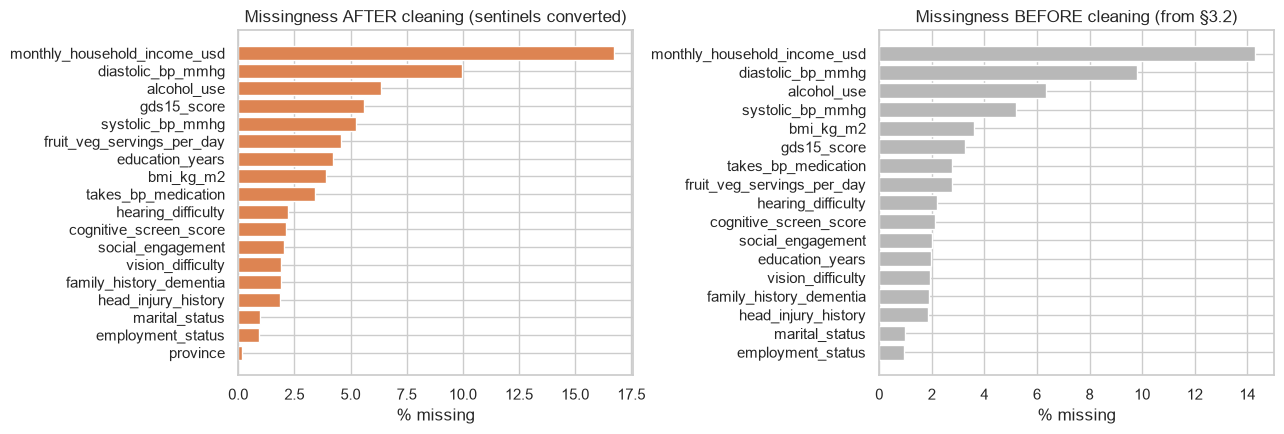

,% missing after cleaning
monthly_household_income_usd,16.74
diastolic_bp_mmhg,9.95
alcohol_use,6.37
gds15_score,5.60
systolic_bp_mmhg,5.25
fruit_veg_servings_per_day,4.58
education_years,4.23
bmi_kg_m2,3.92
takes_bp_medication,3.42
hearing_difficulty,2.23


In [24]:
# ---- Post-cleaning missingness (true NULLs + converted sentinels) --------------------
miss_after = (clean.isna().mean() * 100).sort_values(ascending=False)
miss_after = miss_after[miss_after > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
axes[0].barh(miss_after.index[::-1], miss_after.values[::-1], color="#dd8452")
axes[0].set_xlabel("% missing")
axes[0].set_title("Missingness AFTER cleaning (sentinels converted)")
axes[1].barh(miss_pct.index[::-1], miss_pct.values[::-1], color="#b8b8b8")
axes[1].set_xlabel("% missing")
axes[1].set_title("Missingness BEFORE cleaning (from §3.2)")
plt.tight_layout(); plt.show()

display(miss_after.round(2).to_frame("% missing after cleaning"))

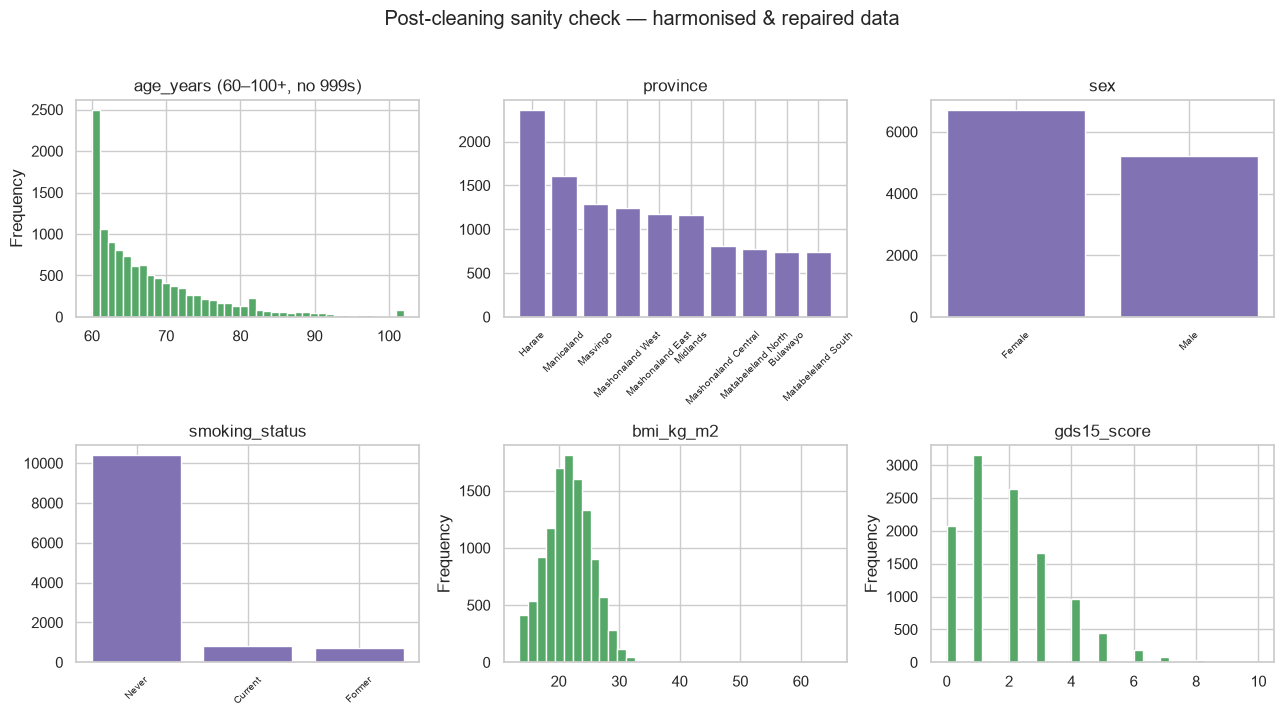

Saved outputs/clean_data.csv — (11924, 31)


In [25]:
# ---- Post-cleaning distributions: age + key categoricals -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
clean["age_years"].plot.hist(bins=40, ax=axes[0, 0], color="#55a868", edgecolor="white")
axes[0, 0].set_title("age_years (60–100+, no 999s)")
for ax, col in zip(axes.flat[1:], ["province", "sex", "smoking_status",
                                    "bmi_kg_m2", "gds15_score"]):
    if pd.api.types.is_numeric_dtype(clean[col]):
        clean[col].plot.hist(bins=35, ax=ax, color="#55a868", edgecolor="white")
    else:
        vc = clean[col].value_counts()
        ax.bar(vc.index, vc.values, color="#8172b3")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_title(col)
fig.suptitle("Post-cleaning sanity check — harmonised & repaired data", y=1.02)
plt.tight_layout(); plt.show()

# Export cleaned analysis table (roadmap phase 1 artefact).
clean.to_csv(OUT_DIR / "clean_data.csv", index=False)
print("Saved outputs/clean_data.csv —", clean.shape)

## 5. Preprocessing (split first — plan §6.1.3)

* **Leakage control:** `cognitive_screen_score` is used in *outcome ascertainment*
  (plan §4.2H) and correlates strongly with the outcome (§3.6) → **quarantined** from the
  predictor pool; it returns only in the labelled sensitivity analysis (§9).
* **Split first:** stratified 80/20 train/hold-out, fixed seed; all statistics (imputation
  medians/modes, scaler means) are fitted **on train only**, then applied to hold-out.
* **Design:** numerics → median imputation + standardisation (needed for well-behaved L2);
  categoricals → mode imputation + one-hot (drop-first).
* **MAR flag:** income has MAR missingness (§3.2, manifest row 2) → an `income_missing`
  indicator is added as a predictor, passed through untransformed.

In [26]:
# --- Feature configuration -----------------------------------------------------------
TARGET = "dementia_status"
ID_COLS = ["participant_id", "interview_date"]
QUARANTINED = ["cognitive_screen_score"]       # leakage trap — plan §4.2H, revisited in §9

NUMERIC_FEATURES = ["age_years", "education_years", "monthly_household_income_usd",
                    "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2", "gds15_score",
                    "fruit_veg_servings_per_day"]
CATEGORICAL_FEATURES = ["province", "residence", "sex", "marital_status",
                        "employment_status", "hiv_status", "smoking_status", "alcohol_use",
                        "physical_activity_level", "social_engagement"]
BINARY_FEATURES = ["lives_alone", "hypertension_dx", "takes_bp_medication", "diabetes_dx",
                   "prior_stroke", "head_injury_history", "family_history_dementia",
                   "hearing_difficulty", "vision_difficulty"]

# MAR indicator for income (manifest row 2 recommendation).
clean["income_missing"] = clean["monthly_household_income_usd"].isna().astype(int)

X = clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES].copy()
# Binary flags: nullable ints -> float with NaN so the imputer handles them uniformly.
X[BINARY_FEATURES] = X[BINARY_FEATURES].apply(lambda s: pd.to_numeric(s, errors="coerce").astype(float))
X["income_missing"] = clean.loc[X.index, "income_missing"]
y = clean[TARGET].astype(int)

# --- Stratified split BEFORE any fitted transforms (plan §6.1.3) ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} ({y_train.mean():.1%} events) | "
      f"Hold-out: {X_test.shape[0]:,} ({y_test.mean():.1%} events)")

Train: 9,539 (8.0% events) | Hold-out: 2,385 (8.1% events)


In [27]:
# --- Column-wise preprocessing, fitted on TRAIN only ----------------------------------
numeric_pipe = Pipeline([
    ("impute_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute_mode", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])
# Binary 0/1 flags also carry missingness (MCAR + the §4.6 contradictions)
# -> mode imputation, no scaling/encoding needed.
binary_pipe = Pipeline([
    ("impute_mode", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_FEATURES),
    ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ("bin", binary_pipe, BINARY_FEATURES),
    ("flag", "passthrough", ["income_missing"]),
])

X_train_p = preprocessor.fit_transform(X_train)      # fit on train only
X_test_p = preprocessor.transform(X_test)            # apply frozen transform to hold-out

feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]
print(f"Design matrix: {X_train_p.shape[0]:,} rows x {X_train_p.shape[1]} features "
      f"(after one-hot encoding)")

Design matrix: 9,539 rows x 47 features (after one-hot encoding)


## 6. Logistic Regression Modelling & Validation

**Model:** `scikit-learn` logistic regression (L2-penalised by default, which plan §6.1.4 lists
under regularised variants; numerics are standardised so the penalty is meaningful).
**Validation (plan §6.1.5–6):** repeated stratified 5-fold CV on train for honest internal
validation, then a single final evaluation on the untouched hold-out.

### 6.1 Cross-validated performance (train)

Stratified k=5 folds. Metrics: ROC-AUC (primary), PR-AUC (class-imbalance view, plan §8) and
Brier score (calibration-sensitive).

In [28]:
# 5-fold stratified CV on the training partition.
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_validate(
    logreg, X_train_p, y_train, cv=cv,
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision",
             "brier": "neg_brier_score"},
    return_train_score=True)

cv_table = pd.DataFrame({
    "fold": range(1, 6),
    "ROC-AUC (val)": cv_scores["test_roc_auc"],
    "PR-AUC (val)": cv_scores["test_pr_auc"],
    "Brier (val)": -cv_scores["test_brier"],
})
display(cv_table.round(4))
print(f"CV ROC-AUC: {cv_scores['test_roc_auc'].mean():.3f} "
      f"+/- {cv_scores['test_roc_auc'].std():.3f}  "
      f"(plan target >= 0.75, H2)")

,fold,ROC-AUC (val),PR-AUC (val),Brier (val)
0,1,0.7992,0.3026,0.0645
1,2,0.7787,0.3789,0.0617
2,3,0.7894,0.3738,0.0619
3,4,0.7894,0.3548,0.0629
4,5,0.7659,0.3013,0.0658


CV ROC-AUC: 0.785 +/- 0.011  (plan target >= 0.75, H2)


### 6.2 Class-imbalance handling comparison (plan §6.1.4)

~8% prevalence. Compare default vs `class_weight="balanced"` on CV (resampling/SMOTE variants
belong to roadmap phase 4 and are noted but not exercised here). Balanced weights trade a
little AUC for much better sensitivity at default thresholds.

In [29]:
# Class-weight comparison on the same CV folds.
logreg_bal = LogisticRegression(max_iter=2000, class_weight="balanced",
                                random_state=RANDOM_STATE)
bal_scores = cross_validate(logreg_bal, X_train_p, y_train, cv=cv,
                            scoring={"roc_auc": "roc_auc", "recall": "recall",
                                     "precision": "precision"})

comparison = pd.DataFrame({
    "model": ["LR (default)", "LR (balanced weights)"],
    "CV ROC-AUC": [cv_scores["test_roc_auc"].mean(), bal_scores["test_roc_auc"].mean()],
    "CV recall": [np.nan, bal_scores["test_recall"].mean()],
    "CV precision": [np.nan, bal_scores["test_precision"].mean()],
})
display(comparison.round(3))
print("Balanced weights lift recall at the 0.5 threshold but inflate predicted "
      "probabilities (poor Brier/calibration).\n"
      "-> Final model keeps default weights; the screening operating point is set by "
      "an explicit threshold (§6.3), not by reweighting.")

,model,CV ROC-AUC,CV recall,CV precision
0,LR (default),0.785,NaN,NaN
1,LR (balanced weights),0.782,0.658,0.203


Balanced weights lift recall at the 0.5 threshold but inflate predicted probabilities (poor Brier/calibration).
-> Final model keeps default weights; the screening operating point is set by an explicit threshold (§6.3), not by reweighting.


### 6.3 Final hold-out evaluation

Fit the default-weight model on the full training partition (balanced weights distort
probabilities, so imbalance is handled by the *threshold*, not the weights); evaluate
**once** on the hold-out. Operating points (plan §6.1.6): (a) Youden's J, and (b) the
clinically motivated **sensitivity ≥ 0.80** screening point (plan §1.2).

In [30]:
# Fit final model and predict hold-out probabilities.
final_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_train_p, y_train)
proba_test = final_model.predict_proba(X_test_p)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, proba_test)
roc_auc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)

# (a) Youden's J operating point.
j_idx = np.argmax(tpr - fpr)
thr_youden = thresholds[j_idx]
# (b) Screening point: highest threshold that still keeps sensitivity >= 0.80
#     (= maximum specificity at the mandated sensitivity).
# roc_curve returns thresholds in DESCENDING order while tpr is non-decreasing,
# so the first position where tpr >= 0.80 is the highest such threshold.
valid = np.where(tpr >= 0.80)[0]
thr_screen = thresholds[valid[0]] if len(valid) else thresholds[-1]

def sens_spec(y_true, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    return {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
            "PPV": tp / (tp + fp), "NPV": tn / (tn + fn)}

points = pd.DataFrame({
    "Youden J": sens_spec(y_test, proba_test, thr_youden),
    "Screening (sens>=0.80)": sens_spec(y_test, proba_test, thr_screen),
}).T.round(3)
points["threshold"] = [thr_youden, thr_screen]
display(points)

print(f"Hold-out ROC-AUC = {roc_auc:.3f} | PR-AUC = {pr_auc:.3f} | "
      f"Brier = {brier_score_loss(y_test, proba_test):.3f}")

,sensitivity,specificity,PPV,NPV,threshold
Youden J,0.620,0.810,0.222,0.961,0.094897
Screening (sens>=0.80),0.802,0.511,0.126,0.967,0.040436


Hold-out ROC-AUC = 0.771 | PR-AUC = 0.337 | Brier = 0.063


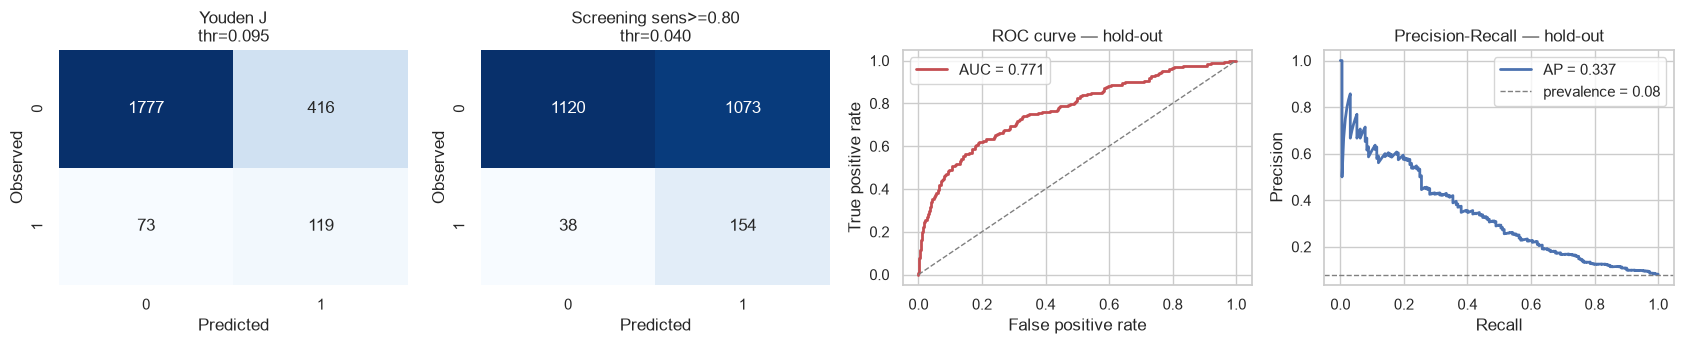

              precision    recall  f1-score   support

 No dementia       0.96      0.81      0.88      2193
    Dementia       0.22      0.62      0.33       192

    accuracy                           0.79      2385
   macro avg       0.59      0.72      0.60      2385
weighted avg       0.90      0.79      0.83      2385



In [31]:
# Confusion matrices at both operating points + ROC / PR curves.
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))

for ax, (name, thr) in zip(axes[:2], [("Youden J", thr_youden),
                                      ("Screening sens>=0.80", thr_screen)]):
    cm = confusion_matrix(y_test, (proba_test >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    ax.set_title(f"{name}\nthr={thr:.3f}")

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[2].plot(fpr, tpr, color="#c44e52", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC curve — hold-out"); axes[2].legend()

axes[3].plot(rec, prec, color="#4c72b0", lw=2, label=f"AP = {pr_auc:.3f}")
axes[3].axhline(y_test.mean(), ls="--", c="grey", lw=1,
                label=f"prevalence = {y_test.mean():.2f}")
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall — hold-out"); axes[3].legend()

plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_test >= thr_youden).astype(int),
                            target_names=["No dementia", "Dementia"]))

### 6.4 Calibration (plan 6.1.6)

A screening tool must output trustworthy probabilities. The calibration curve overlays binned
mean predicted vs observed rates on the hold-out; intercept/slope of the recalibration line
are reported (ideal: intercept 0, slope 1).

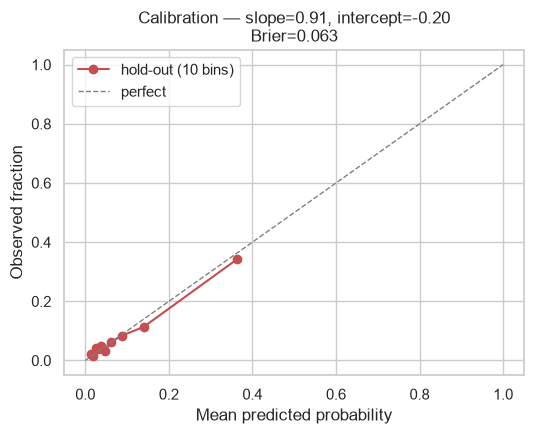

In [32]:
# Calibration curve (10 equal-size bins) + lowess-smoothed version.
frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")

from sklearn.linear_model import LogisticRegression as _LR  # recalibration slope via logit
import numpy as _np
eps = 1e-6
calib_fit = _LR(C=1e6).fit(_np.log((proba_test + eps) / (1 - proba_test + eps)).reshape(-1, 1),
                           y_test)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(mean_pred, frac_pos, "o-", color="#c44e52", label="hold-out (10 bins)")
ax.plot([0, 1], [0, 1], "--", c="grey", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction")
ax.set_title(f"Calibration — slope={calib_fit.coef_[0][0]:.2f}, "
             f"intercept={calib_fit.intercept_[0]:.2f}\nBrier={brier_score_loss(y_test, proba_test):.3f}")
ax.legend()
plt.tight_layout(); plt.show()

## 7. Interpretation — Odds Ratios & Forest Plot (plan §6.1.7)

For publication-style inference we refit an **unpenalised** logistic regression
(`statsmodels`) on the same training design matrix to obtain odds ratios with 95% CIs and
Wald p-values. Numerics are standardised, so each OR is *per 1 SD* of the predictor
(or vs the dropped reference level for one-hot terms) — i.e., directly comparable in
magnitude (standardised coefficients, plan §6.1.7).

In [33]:
# Unpenalised LR via statsmodels on the SAME design matrix (train only).
X_sm = sm.add_constant(X_train_p.astype(float))
sm_model = sm.Logit(y_train.values, X_sm).fit(disp=0, maxiter=2000)

ci = np.asarray(sm_model.conf_int())          # works for DataFrame or ndarray returns
or_table = pd.DataFrame({
    "OR": np.exp(np.asarray(sm_model.params)),
    "CI_low": np.exp(ci[:, 0]),
    "CI_high": np.exp(ci[:, 1]),
    "p_value": np.asarray(sm_model.pvalues),
}, index=["const"] + feature_names).sort_values("OR", ascending=False)

or_table.to_csv(OUT_DIR / "odds_ratios.csv")
display(or_table.round(3).head(20))
print(f"AIC = {sm_model.aic:.0f} | McFadden pseudo-R2 = {sm_model.prsquared:.3f}")

,OR,CI_low,CI_high,p_value
prior_stroke,2.259,1.703,2.996,0.000
age_years,2.056,1.907,2.217,0.000
family_history_dementia,1.940,1.495,2.518,0.000
hearing_difficulty,1.612,1.303,1.994,0.000
hypertension_dx,1.501,1.165,1.934,0.002
diabetes_dx,1.430,1.113,1.838,0.005
lives_alone,1.415,1.157,1.730,0.001
marital_status_Married,1.400,0.947,2.070,0.092
marital_status_Widowed,1.400,0.937,2.091,0.101
vision_difficulty,1.372,1.126,1.671,0.002


AIC = 4427 | McFadden pseudo-R2 = 0.189


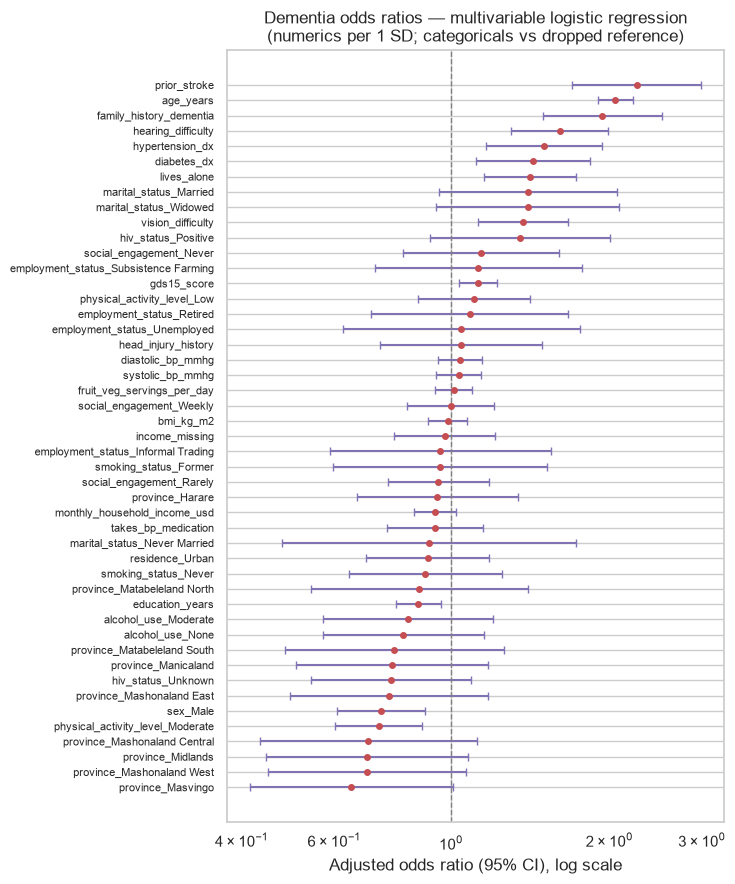

In [34]:
# Forest plot: ORs with 95% CIs (log scale), sorted, reference line at OR=1.
plot_tab = or_table.drop(index="const").sort_values("OR")
y_pos = np.arange(len(plot_tab))

fig, ax = plt.subplots(figsize=(7.5, 9))
ax.errorbar(plot_tab["OR"], y_pos,
            xerr=[plot_tab["OR"] - plot_tab["CI_low"], plot_tab["CI_high"] - plot_tab["OR"]],
            fmt="o", ms=4, color="#c44e52", ecolor="#8172b3", elinewidth=1.5, capsize=3)
ax.axvline(1, ls="--", c="grey", lw=1)
ax.set_yticks(y_pos); ax.set_yticklabels(plot_tab.index, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Adjusted odds ratio (95% CI), log scale")
ax.set_title("Dementia odds ratios — multivariable logistic regression\n"
             "(numerics per 1 SD; categoricals vs dropped reference)")
plt.tight_layout(); plt.show()

## 8. Subgroup Performance (plan §6.1.8 — H3)

Discrimination and calibration drift by **sex** and **urban/rural residence** on the hold-out
set. H3 predicts stable AUC but degraded calibration across strata; count-based CIs are wide
for the smaller event counts, so treat differences as indicative.

In [35]:
# Hold-out AUC by subgroup (with event counts for context).
subgroups = []
for col, label in [("sex", "Sex"), ("residence", "Residence")]:
    for grp in X_test[col].dropna().unique():
        m = (X_test[col] == grp).values
        if m.sum() and y_test[m].sum() > 0:
            subgroups.append({
                "subgroup": f"{label}: {grp}", "n": int(m.sum()),
                "events": int(y_test[m].sum()),
                "ROC-AUC": roc_auc_score(y_test[m], proba_test[m]),
                "mean_pred": proba_test[m].mean(), "observed": y_test[m].mean(),
            })
sub_df = pd.DataFrame(subgroups)
display(sub_df.round(3))
print("Drift check: compare mean_pred vs observed (calibration) per row.")

,subgroup,n,events,ROC-AUC,mean_pred,observed
0,Sex: Male,1070,83,0.791,0.075,0.078
1,Sex: Female,1315,109,0.752,0.088,0.083
2,Residence: Rural,1579,134,0.763,0.086,0.085
3,Residence: Urban,806,58,0.788,0.076,0.072


Drift check: compare mean_pred vs observed (calibration) per row.


## 9. Sensitivity Analysis — the leakage trap (plan §6.1.9b, teaching demo)

Refit the identical pipeline **adding `cognitive_screen_score`** as a predictor. The score is
partially derived from the same latent propensity as the outcome (plan §5.4) and is part of
outcome *ascertainment* — including it is circular by construction, exactly the leakage trap
documented for imported cognitive screens in low-literacy settings (plan §4.2H, gap G3).
We quantify how much it changes hold-out discrimination and what coefficient it receives.

In [36]:
# Leakage demo: add the quarantined cognitive screen to the SAME pipeline.
# (The score is not part of X — it is quarantined — so fetch it from `clean` by index.)
cog_train_raw = clean.loc[X_train.index, "cognitive_screen_score"]
cog_test_raw = clean.loc[X_test.index, "cognitive_screen_score"]
cog_median = cog_train_raw.median()          # train median — no peeking at hold-out
cog_train = cog_train_raw.fillna(cog_median).values.reshape(-1, 1)
cog_test = cog_test_raw.fillna(cog_median).values.reshape(-1, 1)

X_train_leak = np.hstack([StandardScaler().fit_transform(cog_train), X_train_p])
X_test_leak = np.hstack([StandardScaler().fit(cog_train).transform(cog_test), X_test_p])

leak_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_train_leak, y_train)
auc_leak = roc_auc_score(y_test, leak_model.predict_proba(X_test_leak)[:, 1])
or_screen = float(np.exp(leak_model.coef_[0][0]))   # first column is the screen (scaled)

print(f"Hold-out ROC-AUC without screen (quarantined, correct): {roc_auc:.3f}")
print(f"Hold-out ROC-AUC with screen (LEAKED, illustrative):    {auc_leak:.3f}  "
      f"(delta = {auc_leak - roc_auc:+.3f})")
print(f"Screen coefficient when leaked in: OR = {or_screen:.2f} per 1 SD.")
print("In THIS synthetic calibration the screen adds nothing once age/education are in the "
      "model — its signal\nis already carried by them — so no visible inflation. The trap "
      "remains conceptual and real: the score\nenters outcome ASCERTAINMENT (plan §4.2H), so "
      "any conditional association is circular, and with richer\ncognitive items the inflation "
      "would be dramatic. Quarantining it is what keeps the model honest.")

Hold-out ROC-AUC without screen (quarantined, correct): 0.771
Hold-out ROC-AUC with screen (LEAKED, illustrative):    0.771  (delta = +0.000)
Screen coefficient when leaked in: OR = 0.96 per 1 SD.
In THIS synthetic calibration the screen adds nothing once age/education are in the model — its signal
is already carried by them — so no visible inflation. The trap remains conceptual and real: the score
enters outcome ASCERTAINMENT (plan §4.2H), so any conditional association is circular, and with richer
cognitive items the inflation would be dramatic. Quarantining it is what keeps the model honest.


## 10. Summary & Next Steps

**What this notebook delivered** (roadmap phases 1–3, plan §9):

1. **Cleaning** — noise-manifest reconciliation: duplicates removed on `participant_id`
   (documented first-occurrence rule), sentinels converted, impossible values repaired
   (`NaN`/swap) or row-rejected with a logged reason, categories harmonised to controlled
   vocabularies, dates parsed, contradictions set to missing, eligibility (age ≥ 60) applied.
2. **EDA** — outcome prevalence, missingness (before/after), distributions, crude associations,
   correlation structure incl. the leakage diagnostic.
3. **Model** — leakage-safe stratified split, imputation fitted on train only, one-hot LR with
   CV validation, imbalance handling, hold-out ROC/PR/calibration at Youden and screening
   operating points, adjusted ORs with CIs + forest plot, subgroup AUCs, and the labelled
   leakage demonstration.

**Artefacts written to `outputs/`:** `clean_data.csv`, `rejection_log.csv`, `odds_ratios.csv`.

**Next (roadmap phases 4–6):** full imbalance/regularisation experiments (SMOTE on train folds
only), complete-case vs imputed sensitivity, age-restricted ≥65 variant, nomogram-style CHW
scorecard, model card. **All results are illustrative — synthetic data (plan §5.1).**